In [ ]:
#TRIAL 2 FOR NYC REALESTATE

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
prices = pd.read_csv("Trial_2_Housing_Prices.csv")

In [4]:
prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [5]:
prices = prices[["price","area","bedrooms","bathrooms","stories","parking"]]

In [6]:
prices

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [7]:
prices.select_dtypes(include='number').corr()["price"]

price        1.000000
area         0.535997
bedrooms     0.366494
bathrooms    0.517545
stories      0.420712
parking      0.384394
Name: price, dtype: float64

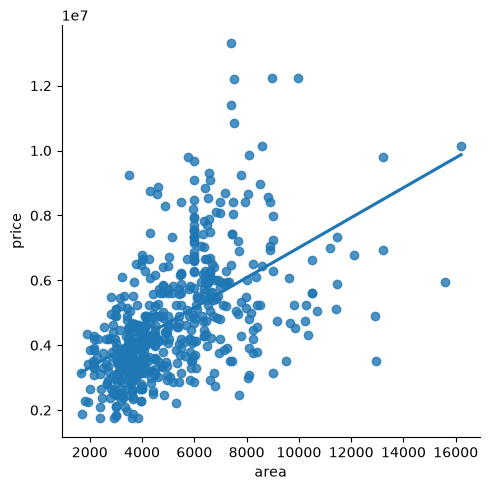

In [9]:
sns.lmplot(x="area", y="price", data=prices, ci=None )

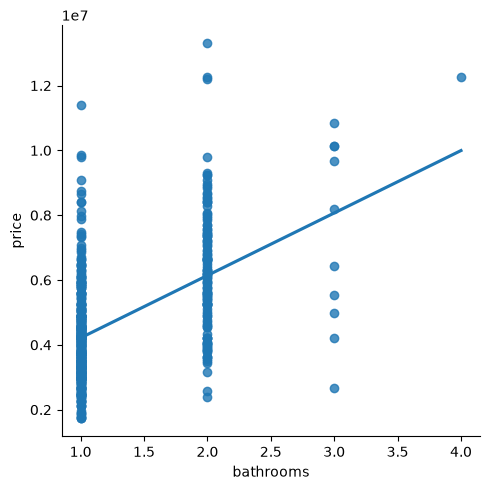

In [10]:
sns.lmplot(x="bathrooms", y="price", data=prices, ci=None )

<Axes: ylabel='Frequency'>

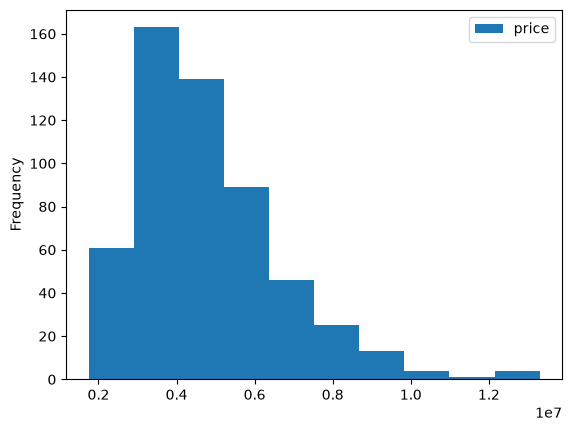

In [11]:
prices.plot.hist(y="price")

In [12]:
prices[prices.isnull().any(axis=1)]

,price,area,bedrooms,bathrooms,stories,parking


In [14]:
#TIME TO TEST

In [31]:
train = prices[prices["price"]< 6500000].copy()
test = prices[prices["price"] >=6500000].copy()

In [32]:
train.shape

(458, 6)

In [33]:
test.shape

(87, 6)

In [34]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [35]:
predictors = ["area", "bathrooms"]
target = "price"

In [36]:
reg.fit(train[predictors], train["price"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 262.84,796085.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['area','bathrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.929e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [37]:
predictions = reg.predict(test[predictors])

In [38]:
predictions

array([5471645.99689219, 7468598.2688908 , 6139272.20663975,
       5492673.59404959, 4675560.48353289, 6288759.10740889,
       6572631.66903384, 8575510.29827652, 4854295.05937082,
       5032694.90623139, 6194804.37815529, 5894491.66070757,
       5242970.87780542, 4441293.73617942, 5571527.08338985,
       4302320.63398898, 5256113.1260288 , 5755518.55851713,
       4730423.19709371, 5208801.03242464, 3860741.0936835 ,
       5401992.08130829, 4841152.81114744, 4719909.39851501,
       5834372.0478574 , 5240342.42816075, 5098406.14734828,
       5057999.90683317, 5610953.82805999, 4966983.6651145 ,
       5486102.4699379 , 4565165.59845652, 4804019.78714463,
       5883977.86212887, 4523110.40414171, 5361251.11181582,
       5487942.38468918, 5886941.04075091, 4302320.63398898,
       5098406.14734828, 4446885.36444613, 5193030.33455659,
       5224571.7302927 , 5098406.14734828, 5098406.14734828,
       5098406.14734828, 5098406.14734828, 4460027.6126695 ,
       4651569.70775345,

In [39]:
test["predictions"] = predictions

In [40]:
test

,price,area,bedrooms,bathrooms,stories,parking,predictions
0,13300000,7420,4,2,3,2,5.471646e+06
1,12250000,8960,4,4,4,3,7.468598e+06
2,12250000,9960,3,2,2,2,6.139272e+06
3,12215000,7500,4,2,2,3,5.492674e+06
4,11410000,7420,4,1,2,2,4.675560e+06
...,...,...,...,...,...,...,...
82,6615000,10500,3,2,1,1,6.281208e+06
83,6580000,6000,3,2,4,0,5.098406e+06
84,6510000,3760,3,1,2,2,3.713548e+06
85,6510000,8250,3,2,3,0,5.689807e+06


In [41]:
test["predictions"] = test["predictions"].round()

In [42]:
test

,price,area,bedrooms,bathrooms,stories,parking,predictions
0,13300000,7420,4,2,3,2,5471646.0
1,12250000,8960,4,4,4,3,7468598.0
2,12250000,9960,3,2,2,2,6139272.0
3,12215000,7500,4,2,2,3,5492674.0
4,11410000,7420,4,1,2,2,4675560.0
...,...,...,...,...,...,...,...
82,6615000,10500,3,2,1,1,6281208.0
83,6580000,6000,3,2,4,0,5098406.0
84,6510000,3760,3,1,2,2,3713548.0
85,6510000,8250,3,2,3,0,5689807.0


In [43]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["price"], test["predictions"])

In [44]:
error

2880445.356321839

In [45]:
#not great error since the area and bathrooms werent too correlated 

In [47]:
prices.describe()["price"]

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [48]:
2880445.356321839 < 1.870440e+06

False

In [49]:
#Error is not below the standard deviation which means this model is not very accurate

In [50]:
errors = (test["price"] - predictions).abs()

In [51]:
errors

0     7.828354e+06
1     4.781402e+06
2     6.110728e+06
3     6.722326e+06
4     6.734440e+06
          ...     
82    3.337915e+05
83    1.481594e+06
84    2.796452e+06
85    8.201927e+05
86    2.031573e+06
Name: price, Length: 87, dtype: float64

In [ ]:
#Not great should try again